## Preprocesamiento

In [23]:
import pandas as pd
import os

# 1. Cargar el archivo de metadatos
# Cambia 'dataset/HAM10000_metadata.csv' por tu ruta si es diferente
df = pd.read_csv('dataset/HAM10000_metadata.csv')

print("--- PRIMER VISTAZO A LOS DATOS ---")
print(f"Total de registros de lesiones: {len(df)}")
print("\nPrimeras 5 filas del dataset:")
print(df.head())

print("\n--- DISTRIBUCIÓN DE CLASES (Tipos de lesiones) ---")
# Diccionario para entender las abreviaturas oficiales del dataset
lesion_type_dict = {
    'nv': 'Melanocytic nevi (Lunar común)',
    'mel': 'Melanoma (Maligno)',
    'bcl': 'Basal cell carcinoma (Cáncer)',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses (Pre-cáncer)',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma',
    'akiec': 'Actinic keratoses'
}

# Contar cuántas imágenes hay por cada tipo
print(df['dx'].value_counts())

--- PRIMER VISTAZO A LOS DATOS ---
Total de registros de lesiones: 10015

Primeras 5 filas del dataset:
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear

--- DISTRIBUCIÓN DE CLASES (Tipos de lesiones) ---
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


Mapeo completado. Imágenes indexadas: 10015 de 10015


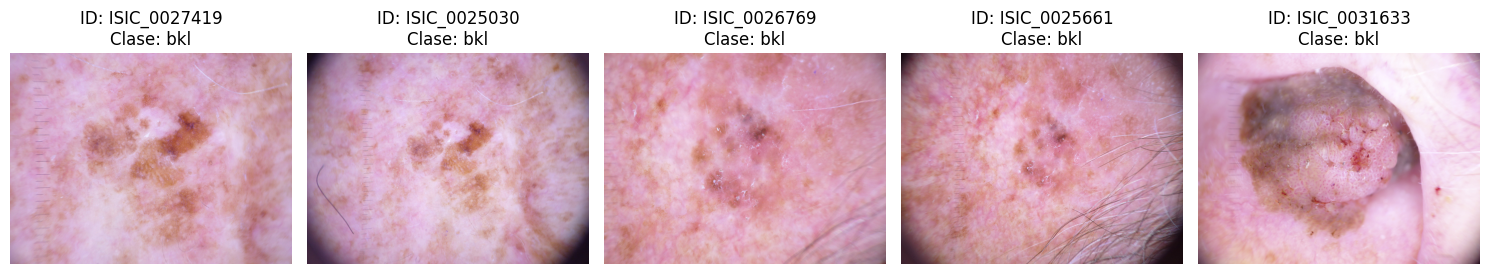

In [24]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# 1. Definir las rutas a las carpetas donde descomprimiste las imágenes
# Ajusta estos nombres si tus carpetas se llaman diferente
folder_part1 = 'dataset/HAM10000_images_part_1'
folder_part2 = 'dataset/HAM10000_images_part_2'

# 2. Crear un diccionario de mapeo: { 'nombre_imagen': 'ruta_completa_al_archivo' }
image_path_mapping = {}

# Escanear parte 1
if os.path.exists(folder_part1):
    for filename in os.listdir(folder_part1):
        if filename.endswith('.jpg'):
            id_img = os.path.splitext(filename)[0]
            image_path_mapping[id_img] = os.path.join(folder_part1, filename)

# Escanear parte 2
if os.path.exists(folder_part2):
    for filename in os.listdir(folder_part2):
        if filename.endswith('.jpg'):
            id_img = os.path.splitext(filename)[0]
            image_path_mapping[id_img] = os.path.join(folder_part2, filename)

print(f"Mapeo completado. Imágenes indexadas: {len(image_path_mapping)} de 10015")

# 3. Función para mostrar las primeras 5 imágenes del DataFrame
plt.figure(figsize=(15, 5))

for i, row in df.head(5).iterrows():
    img_id = row['image_id']
    lesion_class = row['dx']
    
    plt.subplot(1, 5, i + 1)
    
    # Validar si la imagen existe en nuestro mapeo antes de abrirla
    if img_id in image_path_mapping:
        img_path = image_path_mapping[img_id]
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(f"ID: {img_id}\nClase: {lesion_class}")
        plt.axis('off')
    else:
        plt.text(0.5, 0.5, f"No encontrada:\n{img_id}", ha='center', va='center')
        plt.axis('off')

plt.tight_layout()
plt.show()

In [25]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# 1. Definir qué transformaciones le haremos a las imágenes "al vuelo"
# Las redes neuronales convolucionales necesitan que todas las imágenes midan lo mismo
transformacion = transforms.Compose([
    transforms.Resize((224, 224)), # Redimensionar a 224x224 para optimizar la GPU
    transforms.ToTensor(),         # Convertir la imagen de formato clásico a Tensor de PyTorch
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalización estándar
])

# 2. Crear la clase Dataset para el HAM10000
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, image_paths, transform=None):
        self.df = dataframe
        self.image_paths = image_paths
        self.transform = transform
        
        # Mapear las etiquetas de texto (nv, mel...) a números (0, 1, 2...) que entienda la IA
        self.label_mapping = {label: idx for idx, label in enumerate(self.df['dx'].unique())}
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # Obtener los datos de la fila actual
        row = self.df.iloc[idx]
        img_id = row['image_id']
        label_text = row['dx']
        label = self.label_mapping[label_text] # Convertir texto a número
        
        # Buscar la ruta física de la imagen usando el mapeo que ya completaste
        img_path = self.image_paths[img_id]
        
        # Leer la imagen del disco duro justo cuando se necesita
        imagen = Image.open(img_path).convert('RGB')
        
        if self.transform:
            imagen = self.transform(imagen)
            
        return imagen, label

# 3. Instanciar tu Dataset real del TFM
dataset_tfm = HAM10000Dataset(dataframe=df, image_paths=image_path_mapping, transform=transformacion)

print(f"¡Dataset de PyTorch preparado con éxito!")
print(f"Mapeo numérico de clases para tu modelo: {dataset_tfm.label_mapping}")

¡Dataset de PyTorch preparado con éxito!
Mapeo numérico de clases para tu modelo: {'bkl': 0, 'nv': 1, 'df': 2, 'mel': 3, 'vasc': 4, 'bcc': 5, 'akiec': 6}


## Fase 1: División de Datos (Train/Validation Split) y DataLoaders

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# ==========================================================
# 1. DICCIONARIO GLOBAL E INMUTABLE (Plantilla Unificada)
# ==========================================================
MAPEO_FIJO_CLASES = {
    'akiec': 0, # Queratosis actínica
    'bcc': 1,   # Carcinoma basocelular
    'bkl': 2,   # Lesión benigna tipo queratosis
    'df': 3,    # Dermatofibroma
    'mel': 4,   # Melanoma (Maligno crítico)
    'nv': 5,    # Nevus melanocítico (Lunar común)
    'vasc': 6   # Lesión vascular
}

# ==========================================================
# 2. ESTRATEGIAS DE PROCESAMIENTO (DATA AUGMENTATION)
# ==========================================================
# El set de Train recibe aumentos geométricos homogéneos para evitar overfitting
transformacion_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), # Volteo espejo horizontal
    transforms.RandomVerticalFlip(p=0.5),   # Volteo espejo vertical
    transforms.RandomRotation(degrees=15),   # Rotación leve (máx 15° para cuidar el eje clínico)
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# El set de Validación se queda estricto (Refleja la realidad médica pura)
transformacion_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================================
# 3. CLASE DATASET ADAPTADA
# ==========================================================
class HAM10000DatasetCorregido(Dataset):
    def __init__(self, dataframe, image_paths, transform=None):
        self.df = dataframe
        self.image_paths = image_paths
        self.transform = transform
        self.label_mapping = MAPEO_FIJO_CLASES
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = row['image_id']
        label = self.label_mapping[row['dx']] # Asignación exacta
        
        img_path = self.image_paths[img_id]
        imagen = Image.open(img_path).convert('RGB')
        
        if self.transform:
            imagen = self.transform(imagen)
            
        return imagen, label

# ==========================================================
# 4. DIVISIÓN PROPORCIONAL Y ESTRATIFICADA (80% Train, 20% Val)
# ==========================================================
df_train, df_val = train_test_split(
    df, 
    test_size=0.20, 
    random_state=42, 
    stratify=df['dx'] # Mantiene los mismos porcentajes de enfermedades en ambos sets
)

# ==========================================================
# 5. INSTANCIAR LOS CARGADORES OFICIALES
# ==========================================================
# Pasamos 'transformacion_train' al entrenamiento y 'transformacion_val' a la validación
dataset_train = HAM10000DatasetCorregido(dataframe=df_train, image_paths=image_path_mapping, transform=transformacion_train)
dataset_val = HAM10000DatasetCorregido(dataframe=df_val, image_paths=image_path_mapping, transform=transformacion_val)

BATCH_SIZE = 32
train_loader = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Guardamos la lista oficial de nombres basada en el mapeo inmutable para sklearn
nombres_clases = list(MAPEO_FIJO_CLASES.keys())

print("✅ ¡Fase 1 configurada con Data Augmentation Homogéneo!")
print(f"-> Clases ordenadas para evaluación: {nombres_clases}")

✅ ¡Fase 1 corregida con éxito! Plantilla unificada.



## Fase 2: Configuración de la Arquitectura del Modelo (DenseNet201 + Transfer Learning)


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.models import DenseNet201_Weights

# 1. Definir el dispositivo de hardware (Forzar el uso de tu RTX 3060)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Enviando el modelo a: {device}")

# 2. Descargar la arquitectura compleja DenseNet201 con pesos preentrenados
modelo_base = models.densenet201(weights=DenseNet201_Weights.DEFAULT)

# 3. Congelar los parámetros del extractor de características
for param in modelo_base.parameters():
    param.requires_grad = False

# 4. Modificar la última capa (Clasificador) para adaptarla a las 7 enfermedades del HAM10000
num_caracteristicas_entrada = modelo_base.classifier.in_features
num_clases = 7

modelo_base.classifier = nn.Sequential(
    nn.Linear(num_caracteristicas_entrada, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, num_clases)
)

# 5. Mover todo el modelo a la memoria de tu tarjeta gráfica
model = modelo_base.to(device)

print("\n=======================================================")
print("  ¡ARQUITECTURA DENSENET201 CONFIGURADA Y EN LA GPU! 🔥 ")
print("=======================================================")
print(f"Capa final modificada correctamente con entrada [{num_caracteristicas_entrada}] y salida [{num_clases}].")

Enviando el modelo a: cuda

  ¡ARQUITECTURA DENSENET201 CONFIGURADA Y EN LA GPU! 🔥 
Capa final modificada correctamente con entrada [1920] y salida [7].


#resnet fase 2


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.models import ResNet50_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Pisamos la variable 'model' con la ResNet50
model = models.resnet50(weights=ResNet50_Weights.DEFAULT)

# Congelamos capas
for param in model.parameters():
    param.requires_grad = False

# Modificamos la capa final (en ResNet se llama 'fc')
num_caracteristicas_entrada = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_caracteristicas_entrada, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, 7)
)

model = model.to(device)
print("¡Variable 'model' reconfigurada con ResNet50!")

import torch.optim as optim

criterion = nn.CrossEntropyLoss()
# Pisamos el optimizador para que ahora apunte a las capas de la ResNet
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
print("¡Optimizador reconfigurado para ResNet50!")



Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\chris/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100.0%


¡Variable 'model' reconfigurada con ResNet50!
¡Optimizador reconfigurado para ResNet50!


## Fase 3: Definición de la Función de Pérdida y el Optimizador

In [41]:
import torch.optim as optim

# 1. Función de Pérdida (Mide qué tan mal se equivoca el modelo)
# CrossEntropyLoss es el estándar para clasificación multiclase (las 7 enfermedades)
criterion = nn.CrossEntropyLoss()

# 2. Optimizador (El algoritmo que ajusta los pesos matemáticos basándose en el error)
# Usamos Adam con un Learning Rate (tasa de aprendizaje) bajo (0.001) para que aprenda con cuidado
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

print("Herramientas de optimización listas.")
print(f"-> Loss Function: CrossEntropyLoss")
print(f"-> Optimizer: Adam (Learning Rate = 0.001)")

# 1. Contar cuántas muestras reales hay de cada clase en el set de entrenamiento
conteo_clases = df_train['dx'].value_counts().to_dict()

# 2. Asegurarnos de ordenar los conteos exactamente en el mismo orden de la plantilla
muestras_por_clase = [conteo_clases[clase] for clase in nombres_clases]

# 3. Calcular los pesos inversos automáticos
total_muestras = sum(muestras_por_clase)
pesos_clases = [total_muestras / (len(muestras_por_clase) * cantidad) for cantidad in muestras_por_clase]

# 4. Convertir a Tensor de PyTorch y enviar a la RTX 3060
pesos_tensor = torch.FloatTensor(pesos_clases).to(device)

# 5. Configurar el criterio definitivo
criterion = nn.CrossEntropyLoss(weight=pesos_tensor)

print("=== NUEVOS PESOS DE BALANCEO SINCRONIZADOS ===")
for clase, peso, cant in zip(nombres_clases, pesos_clases, muestras_por_clase):
    print(f"Enfermedad: {clase:<6} | Cantidad en Train: {cant:<5} | Peso de castigo: {peso:.4f}")

Herramientas de optimización listas.
-> Loss Function: CrossEntropyLoss
-> Optimizer: Adam (Learning Rate = 0.001)
=== NUEVOS PESOS DE BALANCEO SINCRONIZADOS ===
Enfermedad: akiec  | Cantidad en Train: 262   | Peso de castigo: 4.3686
Enfermedad: bcc    | Cantidad en Train: 411   | Peso de castigo: 2.7848
Enfermedad: bkl    | Cantidad en Train: 879   | Peso de castigo: 1.3021
Enfermedad: df     | Cantidad en Train: 92    | Peso de castigo: 12.4410
Enfermedad: mel    | Cantidad en Train: 890   | Peso de castigo: 1.2860
Enfermedad: nv     | Cantidad en Train: 5364  | Peso de castigo: 0.2134
Enfermedad: vasc   | Cantidad en Train: 114   | Peso de castigo: 10.0401


## Fase 4: Bucle de Entrenamiento y Validación en la GPU

In [ ]:
import time

# Configurar el número de épocas (vueltas completas al dataset)
EPOCHS = 20

print(f"Iniciando entrenamiento en: {device}")
print(f"Entrenando durante {EPOCHS} épocas...\n")

for epoch in range(EPOCHS):
    start_time = time.time()
    
    # ==========================================
    #           FASE DE ENTRENAMIENTO
    # ==========================================
    model.train()  # Activar modo entrenamiento
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    # Recorrer los lotes de imágenes de entrenamiento
    for batch_idx, (imagenes, etiquetas) in enumerate(train_loader):
        # Mover los datos a la RTX 3060
        imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)
        
        # Resetear los gradientes del optimizador
        optimizer.zero_grad()
        
        # Paso hacia adelante (Forward pass)
        predicciones = model(imagenes)
        loss = criterion(predicciones, etiquetas)
        
        # Paso hacia atrás (Backpropagation) y optimización
        loss.backward()
        optimizer.step()
        
        # Calcular estadísticas
        running_loss += loss.item()
        _, predicted = torch.max(predicciones.data, 1)
        total_train += etiquetas.size(0)
        correct_train += (predicted == etiquetas).sum().item()
        
        # Imprimir progreso cada 50 lotes para saber que no está congelado
        if batch_idx % 50 == 0:
            print(f"Época [{epoch+1}/{EPOCHS}] -> Lote [{batch_idx}/{len(train_loader)}] | Loss actual: {loss.item():.4f}")
            
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = (correct_train / total_train) * 100
    
    # ==========================================
    #            FASE DE VALIDACIÓN
    # ==========================================
    model.eval()  # Activar modo evaluación (apaga Dropout)
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():  # Desactivar el cálculo de gradientes para ahorrar memoria
        for imagenes, etiquetas in val_loader:
            imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)

            
            predicciones = model(imagenes)
            loss = criterion(predicciones, etiquetas)
            
            val_loss += loss.item()
            _, predicted = torch.max(predicciones.data, 1)
            total_val += etiquetas.size(0)
            correct_val += (predicted == etiquetas).sum().item()
            
    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc = (correct_val / total_val) * 100
    
    epoch_time = time.time() - start_time
    
    # Imprimir el resumen detallado de la época
    print("\n" + "="*60)
    print(f"             RESUMEN DE LA ÉPOCA {epoch+1} ")
    print("="*60)
    print(f"⏱️ Tiempo de la época: {epoch_time:.2f} segundos")
    print(f"📉 Loss Train: {epoch_loss:.4f}  | 📊 Accuracy Train: {epoch_acc:.2f}%")
    print(f"📉 Loss Val:   {epoch_val_loss:.4f}  | 📊 Accuracy Val:   {epoch_val_acc:.2f}%")
    print("="*60 + "\n")

print("¡Entrenamiento inicial completado con éxito! 🎉")

Iniciando entrenamiento en: cuda
Entrenando durante 30 épocas...

Época [1/30] -> Lote [0/251] | Loss actual: 0.4435
Época [1/30] -> Lote [50/251] | Loss actual: 0.6938
Época [1/30] -> Lote [100/251] | Loss actual: 0.8539
Época [1/30] -> Lote [150/251] | Loss actual: 0.6244
Época [1/30] -> Lote [200/251] | Loss actual: 0.6969
Época [1/30] -> Lote [250/251] | Loss actual: 0.7167

             RESUMEN DE LA ÉPOCA 1 
⏱️ Tiempo de la época: 107.19 segundos
📉 Loss Train: 0.6697  | 📊 Accuracy Train: 70.51%
📉 Loss Val:   0.9406  | 📊 Accuracy Val:   71.79%

Época [2/30] -> Lote [0/251] | Loss actual: 0.3622
Época [2/30] -> Lote [50/251] | Loss actual: 0.7184
Época [2/30] -> Lote [100/251] | Loss actual: 0.3747
Época [2/30] -> Lote [150/251] | Loss actual: 0.4955
Época [2/30] -> Lote [200/251] | Loss actual: 0.7000
Época [2/30] -> Lote [250/251] | Loss actual: 0.8043

             RESUMEN DE LA ÉPOCA 2 
⏱️ Tiempo de la época: 110.44 segundos
📉 Loss Train: 0.6238  | 📊 Accuracy Train: 71.78%
📉 Lo

## Fase 5: Evaluación Avanzada, Matriz de Confusión y Reporte Clínico

Extrayendo predicciones del val_loader...

               REPORTE CLÍNICO DE CLASIFICACIÓN
              precision    recall  f1-score   support

       akiec       0.53      0.72      0.61        65
         bcc       0.56      0.58      0.57       103
         bkl       0.48      0.76      0.59       220
          df       0.42      0.74      0.54        23
         mel       0.46      0.59      0.52       223
          nv       0.96      0.78      0.86      1341
        vasc       0.53      0.61      0.57        28

    accuracy                           0.74      2003
   macro avg       0.56      0.68      0.61      2003
weighted avg       0.80      0.74      0.76      2003



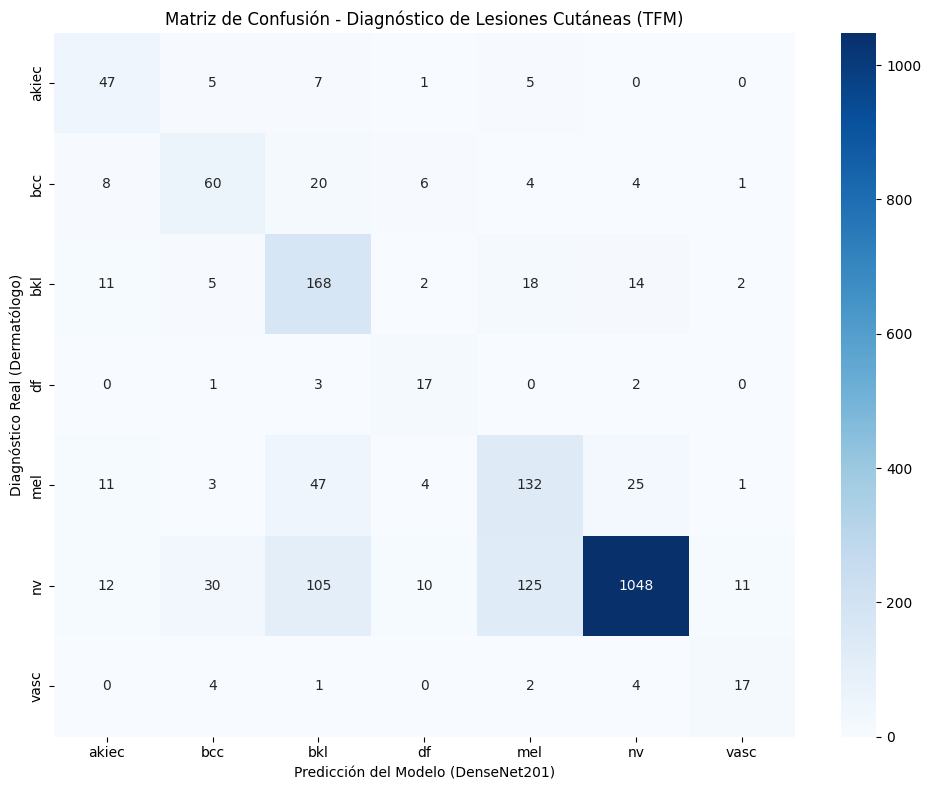

In [46]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================================
# 1. RECOLECTAR PREDICCIONES DEL MODELO EN VALIDACIÓN
# ==========================================================
model.eval()  # Modo evaluación (asegura comportamiento correcto)
todas_las_predicciones = []
todas_las_etiquetas_reales = []

print("Extrayendo predicciones del val_loader...")
with torch.no_grad():
    for imagenes, etiquetas in val_loader:
        imagenes = imagenes.to(device)
        predicciones = model(imagenes)
        
        _, predicted = torch.max(predicciones, 1)
        
        # Mover a CPU y convertir a numpy para sklearn
        todas_las_predicciones.extend(predicted.cpu().numpy())
        todas_las_etiquetas_reales.extend(etiquetas.numpy())

# Obtener los nombres de las clases ordenados según el mapeo numérico
# Ejemplo: ['bkl', 'nv', 'df'...]
nombres_clases = list(MAPEO_FIJO_CLASES.keys())    

# ==========================================================
# 2. IMPRIMIR REPORTE CLÍNICO DE CLASIFICACIÓN
# ==========================================================
print("\n" + "="*60)
# REPORTE DE MÉTRICAS (Precision, Recall, F1-Score)
print("               REPORTE CLÍNICO DE CLASIFICACIÓN")
print("="*60)
print(classification_report(todas_las_etiquetas_reales, todas_las_predicciones, target_names=nombres_clases))
print("="*60)

# ==========================================================
# 3. GENERAR Y DIBUJAR LA MATRIZ DE CONFUSIÓN VISUAL
# ==========================================================
cm = confusion_matrix(todas_las_etiquetas_reales, todas_las_predicciones)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=nombres_clases, 
    yticklabels=nombres_clases
)
plt.title('Matriz de Confusión - Diagnóstico de Lesiones Cutáneas (TFM)')
plt.ylabel('Diagnóstico Real (Dermatólogo)')
plt.xlabel('Predicción del Modelo (DenseNet201)')
plt.tight_layout()
plt.show()



In [ ]:
# ==========================================================
# 4. GUARDAR EL MODELO ENTRENADO EN DISCO DURO
# ==========================================================
nombre_archivo_modelo = 'densenet201_ham10000_tfm.pth'
torch.save(model.state_dict(), nombre_archivo_modelo)
print(f"\n✅ ¡Éxito! El modelo entrenado se ha guardado físicamente como: '{nombre_archivo_modelo}'")